# STEP 3: Classical ML Models (TF-IDF + LR, SVM, Naive Bayes)

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model    import LogisticRegression
from sklearn.svm             import LinearSVC
from sklearn.naive_bayes     import MultinomialNB
from sklearn.pipeline        import Pipeline
from sklearn.metrics         import (classification_report, confusion_matrix,
                                     f1_score, accuracy_score)
from sklearn.model_selection import GridSearchCV

In [2]:
# LOAD DATA
train = pd.read_csv(r'C:\Users\XPRISTO\Desktop\NLP\train.csv')
val   = pd.read_csv(r'C:\Users\XPRISTO\Desktop\NLP\val.csv')
test  = pd.read_csv(r'C:\Users\XPRISTO\Desktop\NLP\test.csv')
le    = joblib.load(r'C:\Users\XPRISTO\Desktop\NLP\label_encoder.pkl')

X_train, y_train = train['clean_text'], train['label']
X_val,   y_val   = val['clean_text'],   val['label']
X_test,  y_test  = test['clean_text'],  test['label']

In [4]:
# TF-IDF VECTORIZER
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),     # unigrams + bigrams
    sublinear_tf=True,      # log normalization
    min_df=2
)

In [5]:
# MODEL PIPELINES
models = {
    'Logistic Regression': Pipeline([
        ('tfidf', tfidf),
        ('clf',   LogisticRegression(max_iter=1000, C=1.0, random_state=42))
    ]),
    'Linear SVM': Pipeline([
        ('tfidf', tfidf),
        ('clf',   LinearSVC(C=1.0, max_iter=2000, random_state=42))
    ]),
    'Naive Bayes': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=50000, ngram_range=(1,2), min_df=2)),
        ('clf',   MultinomialNB(alpha=0.1))
    ]),
}

In [6]:
# TRAIN & EVALUATE
results = {}

for name, pipeline in models.items():
    print(f"\n{'='*50}")
    print(f"Training: {name}")
    print('='*50)

    pipeline.fit(X_train, y_train)

    val_preds  = pipeline.predict(X_val)
    test_preds = pipeline.predict(X_test)

    val_f1  = f1_score(y_val,  val_preds,  average='weighted')
    test_f1 = f1_score(y_test, test_preds, average='weighted')
    test_acc = accuracy_score(y_test, test_preds)

    results[name] = {'val_f1': val_f1, 'test_f1': test_f1, 'test_acc': test_acc}

    print(f"Val   F1 (weighted): {val_f1:.4f}")
    print(f"Test  F1 (weighted): {test_f1:.4f}")
    print(f"Test  Accuracy     : {test_acc:.4f}")
    print(f"\nClassification Report (Test):")
    print(classification_report(y_test, test_preds, target_names=le.classes_))


Training: Logistic Regression
Val   F1 (weighted): 0.8303
Test  F1 (weighted): 0.8223
Test  Accuracy     : 0.8220

Classification Report (Test):
                     precision    recall  f1-score   support

                age       0.95      0.97      0.96      1199
          ethnicity       0.96      0.98      0.97      1194
             gender       0.90      0.81      0.85      1191
  not_cyberbullying       0.59      0.55      0.56      1170
other_cyberbullying       0.59      0.67      0.63      1134
           religion       0.95      0.94      0.95      1200

           accuracy                           0.82      7088
          macro avg       0.82      0.82      0.82      7088
       weighted avg       0.82      0.82      0.82      7088


Training: Linear SVM
Val   F1 (weighted): 0.8229
Test  F1 (weighted): 0.8151
Test  Accuracy     : 0.8162

Classification Report (Test):
                     precision    recall  f1-score   support

                age       0.95      0.97  

In [7]:
# PICK BEST MODEL & SAVE
best_name = max(results, key=lambda k: results[k]['test_f1'])
print(f"\n Best Classical Model: {best_name}")
best_pipeline = models[best_name]
joblib.dump(best_pipeline, r'C:\Users\XPRISTO\Desktop\NLP\best_classical_model.pkl')
print("Saved: best_classical_model.pkl")


 Best Classical Model: Logistic Regression
Saved: best_classical_model.pkl


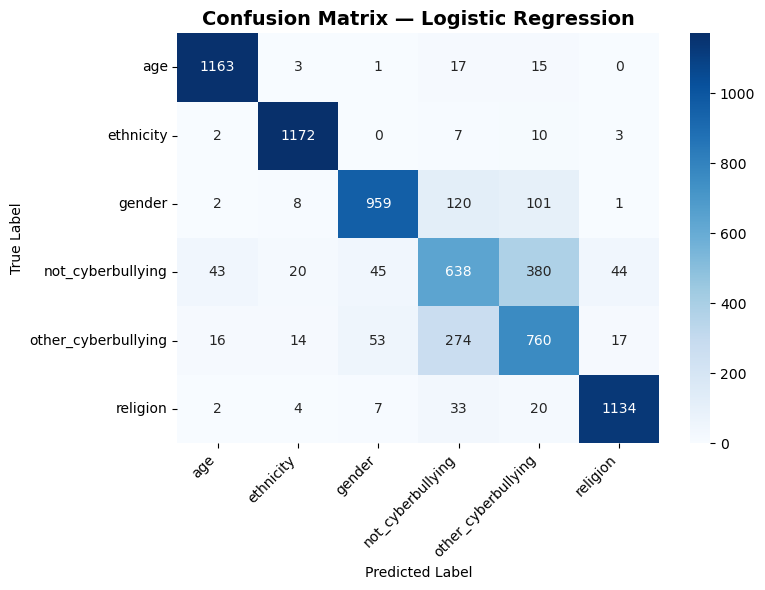

Saved: confusion_matrix_classical.png


In [8]:
# CONFUSION MATRIX FOR BEST MODEL
best_preds = best_pipeline.predict(X_test)
cm = confusion_matrix(y_test, best_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Confusion Matrix — {best_name}', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(r'C:\Users\XPRISTO\Desktop\NLP\confusion_matrix_classical.png', dpi=150)
plt.show()
print("Saved: confusion_matrix_classical.png")

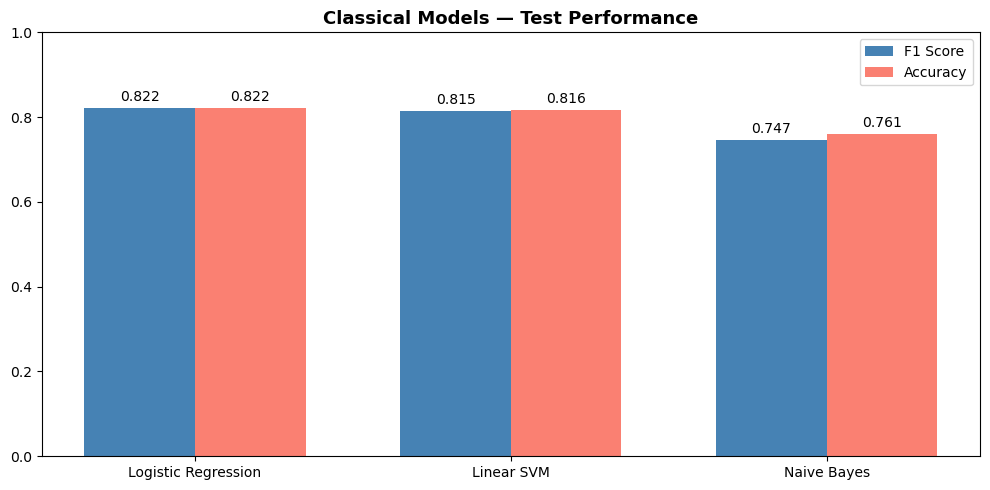

Saved: classical_model_comparison.png


In [9]:
# ── MODEL COMPARISON CHART ───────────────────────────────────
names  = list(results.keys())
f1s    = [results[n]['test_f1']  for n in names]
accs   = [results[n]['test_acc'] for n in names]

x = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, f1s,  width, label='F1 Score',  color='steelblue')
bars2 = ax.bar(x + width/2, accs, width, label='Accuracy',  color='salmon')

ax.set_title('Classical Models — Test Performance', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylim(0, 1)
ax.legend()
ax.bar_label(bars1, fmt='%.3f', padding=3)
ax.bar_label(bars2, fmt='%.3f', padding=3)

plt.tight_layout()
plt.savefig(r'C:\Users\XPRISTO\Desktop\NLP\classical_model_comparison.png', dpi=150)
plt.show()
print("Saved: classical_model_comparison.png")

In [10]:
# HYPERPARAMETER TUNING FOR BEST (LR)
print("\n" + "="*50)
print("Hyperparameter Tuning — Logistic Regression")
print("="*50)

param_grid = {
    'tfidf__max_features': [30000, 50000],
    'tfidf__ngram_range':  [(1,1), (1,2)],
    'clf__C':              [0.1, 1.0, 10.0],
}

grid = GridSearchCV(
    models['Logistic Regression'],
    param_grid,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)
grid.fit(X_train, y_train)

print(f"\nBest params : {grid.best_params_}")
print(f"Best CV F1  : {grid.best_score_:.4f}")

tuned_f1 = f1_score(y_test, grid.predict(X_test), average='weighted')
print(f"Test F1 (tuned): {tuned_f1:.4f}")

joblib.dump(grid.best_estimator_, r'C:\Users\XPRISTO\Desktop\NLP\tuned_lr_model.pkl')
print("Saved: tuned_lr_model.pkl")
print("\nClassical ML step complete.")


Hyperparameter Tuning — Logistic Regression
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best params : {'clf__C': 1.0, 'tfidf__max_features': 30000, 'tfidf__ngram_range': (1, 2)}
Best CV F1  : 0.8212
Test F1 (tuned): 0.8209
Saved: tuned_lr_model.pkl

Classical ML step complete.
